# FTW Baseline — Result Visualization

Displays training/test results for the 3-class U-Net + EfficientNet-B3 baseline.
Set `TEST_DIR` below to point at a specific run's output folder.

In [ ]:
import glob
import os
import random

import subprocess
import geopandas as gpd
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio
from matplotlib.colors import ListedColormap

from ftw_tools.training.datasets import FTW
from rasterio.transform import Affine

random.seed(42)

In [ ]:

def run_sample_inference(filenames, idx, checkpoint, test_dir):
    stacked_tif = f"{test_dir}/sample_{idx}_stacked.tif"
    pred_tif = f"{test_dir}/sample_{idx}_pred.tif"
    with rasterio.open(filenames["window_b"]) as src:
        profile, data_b = src.profile.copy(), src.read()
    with rasterio.open(filenames["window_a"]) as src:
        data_a = src.read()
    stack = np.vstack([data_b, data_a])
    # FTW tiles are south-up (transform.e > 0); `ftw inference run` assumes north-up for
    # patch placement, so flip rows + rewrite the transform before writing the input.
    t = profile["transform"]
    flipped = t.e > 0
    if flipped:
        stack = stack[:, ::-1, :]
        profile["transform"] = Affine(t.a, t.b, t.c, t.d, -t.e, t.f + t.e * stack.shape[1])
    profile.update(count=stack.shape[0])
    with rasterio.open(stacked_tif, "w", **profile) as dst:
        dst.write(stack)
    result = subprocess.run(
        [
            "ftw", "inference", "run", stacked_tif,
            "-m", checkpoint,
            "-o", pred_tif,
            "-r", "1",
            "--gpu=-1",
            "-ps", "256",
            "-bs", "1",
            "--num_workers", "1",
            "-f",
        ],
        capture_output=True, text=True,
        encoding="utf-8", errors="replace",
    )
    if result.returncode != 0:
        print(result.stdout)
        print("STDERR:\n", result.stderr)
        raise RuntimeError(f"ftw inference run failed for sample {idx}")
    with rasterio.open(pred_tif) as src:
        pred = src.read(1)
    # Flip prediction back to match the original south-up orientation of mask/image.
    if flipped:
        pred = pred[::-1, :]
    return pred


def plot_sample_predictions(ds, indices, checkpoint, test_dir, cmap):
    fig, axes = plt.subplots(len(indices), 4, figsize=(18, 4 * len(indices)))
    if len(indices) == 1:
        axes = axes[np.newaxis, :]
    for row, idx in enumerate(indices):
        sample = ds[idx]
        img, mask = sample["image"], sample["mask"].numpy()
        pred = run_sample_inference(ds.filenames[idx], idx, checkpoint, test_dir)
        rgb = img[:3].permute(1, 2, 0).numpy()
        rgb = np.clip((rgb - rgb.min()) / (rgb.max() - rgb.min() + 1e-8), 0, 1)
        overlay = np.zeros((*pred.shape, 4), dtype=np.float32)
        overlay[pred == 1] = [0.3, 0.8, 0.3, 0.4]
        overlay[pred == 2] = [0.9, 0.2, 0.2, 0.7]
        panels = [
            (rgb,  f"RGB (sample {idx})", {}),
            (mask, "Ground Truth",        {"cmap": cmap, "vmin": 0, "vmax": 3, "interpolation": "nearest"}),
            (pred, "Prediction",          {"cmap": cmap, "vmin": 0, "vmax": 3, "interpolation": "nearest"}),
        ]
        for col, (data, title, kw) in enumerate(panels):
            axes[row, col].imshow(data, **kw)
            axes[row, col].set_title(title)
            axes[row, col].axis("off")
        axes[row, 3].imshow(rgb)
        axes[row, 3].imshow(overlay)
        axes[row, 3].set_title("Prediction Overlay")
        axes[row, 3].axis("off")
    legend_patches = [
        mpatches.Patch(color="#888888", label="Background"),
        mpatches.Patch(color="#4CAF50", label="Crop"),
        mpatches.Patch(color="#F44336", label="Boundary"),
    ]
    fig.legend(handles=legend_patches, loc="lower center", ncol=3, fontsize=12)
    plt.tight_layout(rect=[0, 0.03, 1, 1])
    plt.savefig(f"{test_dir}/sample_predictions.png", dpi=150, bbox_inches="tight")
    plt.show()


def plot_full_scene_results(test_dir, cmap, simplify=15, min_size=500):
    pred_tifs = sorted(glob.glob(f"{test_dir}/sample_*_pred.tif"))
    if not pred_tifs:
        print(f"No pred TIFs found in {test_dir}. Run section 2 first.")
        return
    fig, axes = plt.subplots(len(pred_tifs), 2, figsize=(12, 5 * len(pred_tifs)))
    if len(pred_tifs) == 1:
        axes = axes[np.newaxis, :]
    for row, pred_tif in enumerate(pred_tifs):
        fields_parquet = pred_tif.replace("_pred.tif", "_fields.parquet")
        result = subprocess.run(
            [
                "ftw", "inference", "polygonize",
                pred_tif,
                "-o", fields_parquet,
                "-f",
                "--simplify", str(simplify),
                "--min_size", str(min_size)
            ],
            capture_output=True, text=True,
            encoding="utf-8", errors="replace",
        )
        if result.returncode != 0:
            print(result.stdout)
            print("STDERR:\n", result.stderr)
            raise RuntimeError(f"ftw inference polygonize failed for {pred_tif}")
        with rasterio.open(pred_tif) as src:
            pred_raster = src.read(1)
        fields = gpd.read_parquet(fields_parquet)
        name = os.path.basename(pred_tif).replace("_pred.tif", "")
        axes[row, 0].imshow(pred_raster, cmap=cmap, vmin=0, vmax=3, interpolation="nearest")
        axes[row, 0].set_title(f"{name} — Prediction Raster")
        axes[row, 0].axis("off")
        fields.plot(ax=axes[row, 1], facecolor="#4CAF5066", edgecolor="#F44336", linewidth=0.5)
        axes[row, 1].set_title(f"{name} — Polygons (n={len(fields)})")
        axes[row, 1].axis("off")
    plt.tight_layout()
    plt.savefig(f"{test_dir}/full_scene_results.png", dpi=150, bbox_inches="tight")
    plt.show()


def plot_polygon_size_distribution(test_dir):
    parquets = sorted(glob.glob(f"{test_dir}/sample_*_fields.parquet"))
    if not parquets:
        print("No fields parquets found. Run section 3 first.")
        return
    fields_all = gpd.GeoDataFrame(pd.concat([gpd.read_parquet(f) for f in parquets], ignore_index=True))
    fields_utm = fields_all.to_crs(fields_all.estimate_utm_crs())
    areas_ha = fields_utm.geometry.area / 10_000
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    axes[0].hist(areas_ha, bins=50, color="#4CAF50", edgecolor="white")
    axes[0].set(xlabel="Field area (ha)", ylabel="Count", title="Field Size Distribution")
    axes[1].hist(areas_ha[areas_ha < 20], bins=50, color="#2196F3", edgecolor="white")
    axes[1].set(xlabel="Field area (ha) — clipped at 20 ha", ylabel="Count", title="Field Size Distribution (< 20 ha)")
    plt.tight_layout()
    plt.show()
    print(f"Total: {len(fields_utm)}  Median: {areas_ha.median():.2f} ha  "
          f"Mean: {areas_ha.mean():.2f} ha  Max: {areas_ha.max():.2f} ha")

## 1. Metrics Summary

In [ ]:
RUN_ID = "7v9677na"
TEST_DIR = f"../outputs/test_{RUN_ID}"
METRICS_CSV = f"{TEST_DIR}/test_metrics_{RUN_ID}.csv"
CHECKPOINT_FOR_TEST = f"../wandb/{RUN_ID}/checkpoints/epoch=84-val/iou=0.000.ckpt"
DATA_DIR = "../data/ftw"

os.makedirs(TEST_DIR, exist_ok=True)
if not os.path.exists(METRICS_CSV):
    if not os.path.exists(CHECKPOINT_FOR_TEST):
        print(f"Checkpoint not found: {CHECKPOINT_FOR_TEST}")
    else:
        result = subprocess.run(
            [
                "ftw", "model", "test",
                "-m", CHECKPOINT_FOR_TEST,
                "--dir", DATA_DIR,
                "-c", "austria",
                "-p3", "-t3",
                "--gpu=-1",
                "-o", METRICS_CSV,
            ],
            capture_output=True, text=True,
            encoding="utf-8", errors="replace",
        )
        print(result.stdout)
        if result.returncode != 0:
            print("STDERR:\n", result.stderr)

try:
    df = pd.read_csv(METRICS_CSV)
    display(df.T)
except FileNotFoundError:
    print(f"Metrics file not found: {METRICS_CSV}")

,0
train_checkpoint,../wandb/7v9677na/checkpoints/epoch=84-val/iou...
countries,austria
pixel_level_iou,0.726111
pixel_level_precision,0.845778
pixel_level_recall,0.836921
object_level_precision,0.521526
object_level_recall,0.341582
object_level_f1,0.412796


## 2. Sample Patch Predictions

Loads individual 256x256 Austria test patches, stacks window_b + window_a, and runs
`inference_run` (same code path as `ftw inference run`) on each.

In [4]:
N_SAMPLES = 6
CMAP = ListedColormap(["#888888", "#4CAF50", "#F44336", "#000000"])

ds = FTW(root=DATA_DIR, countries=["austria"], split="test", load_boundaries=True)
indices = random.sample(range(len(ds)), min(N_SAMPLES, len(ds)))
print(f"Selected {len(indices)} samples")

Loading 3 Class Masks, with Boundaries
Temporal option:  stacked
Using window B first, then window A
Selecting: 745 samples (split=test)
Selected 6 samples


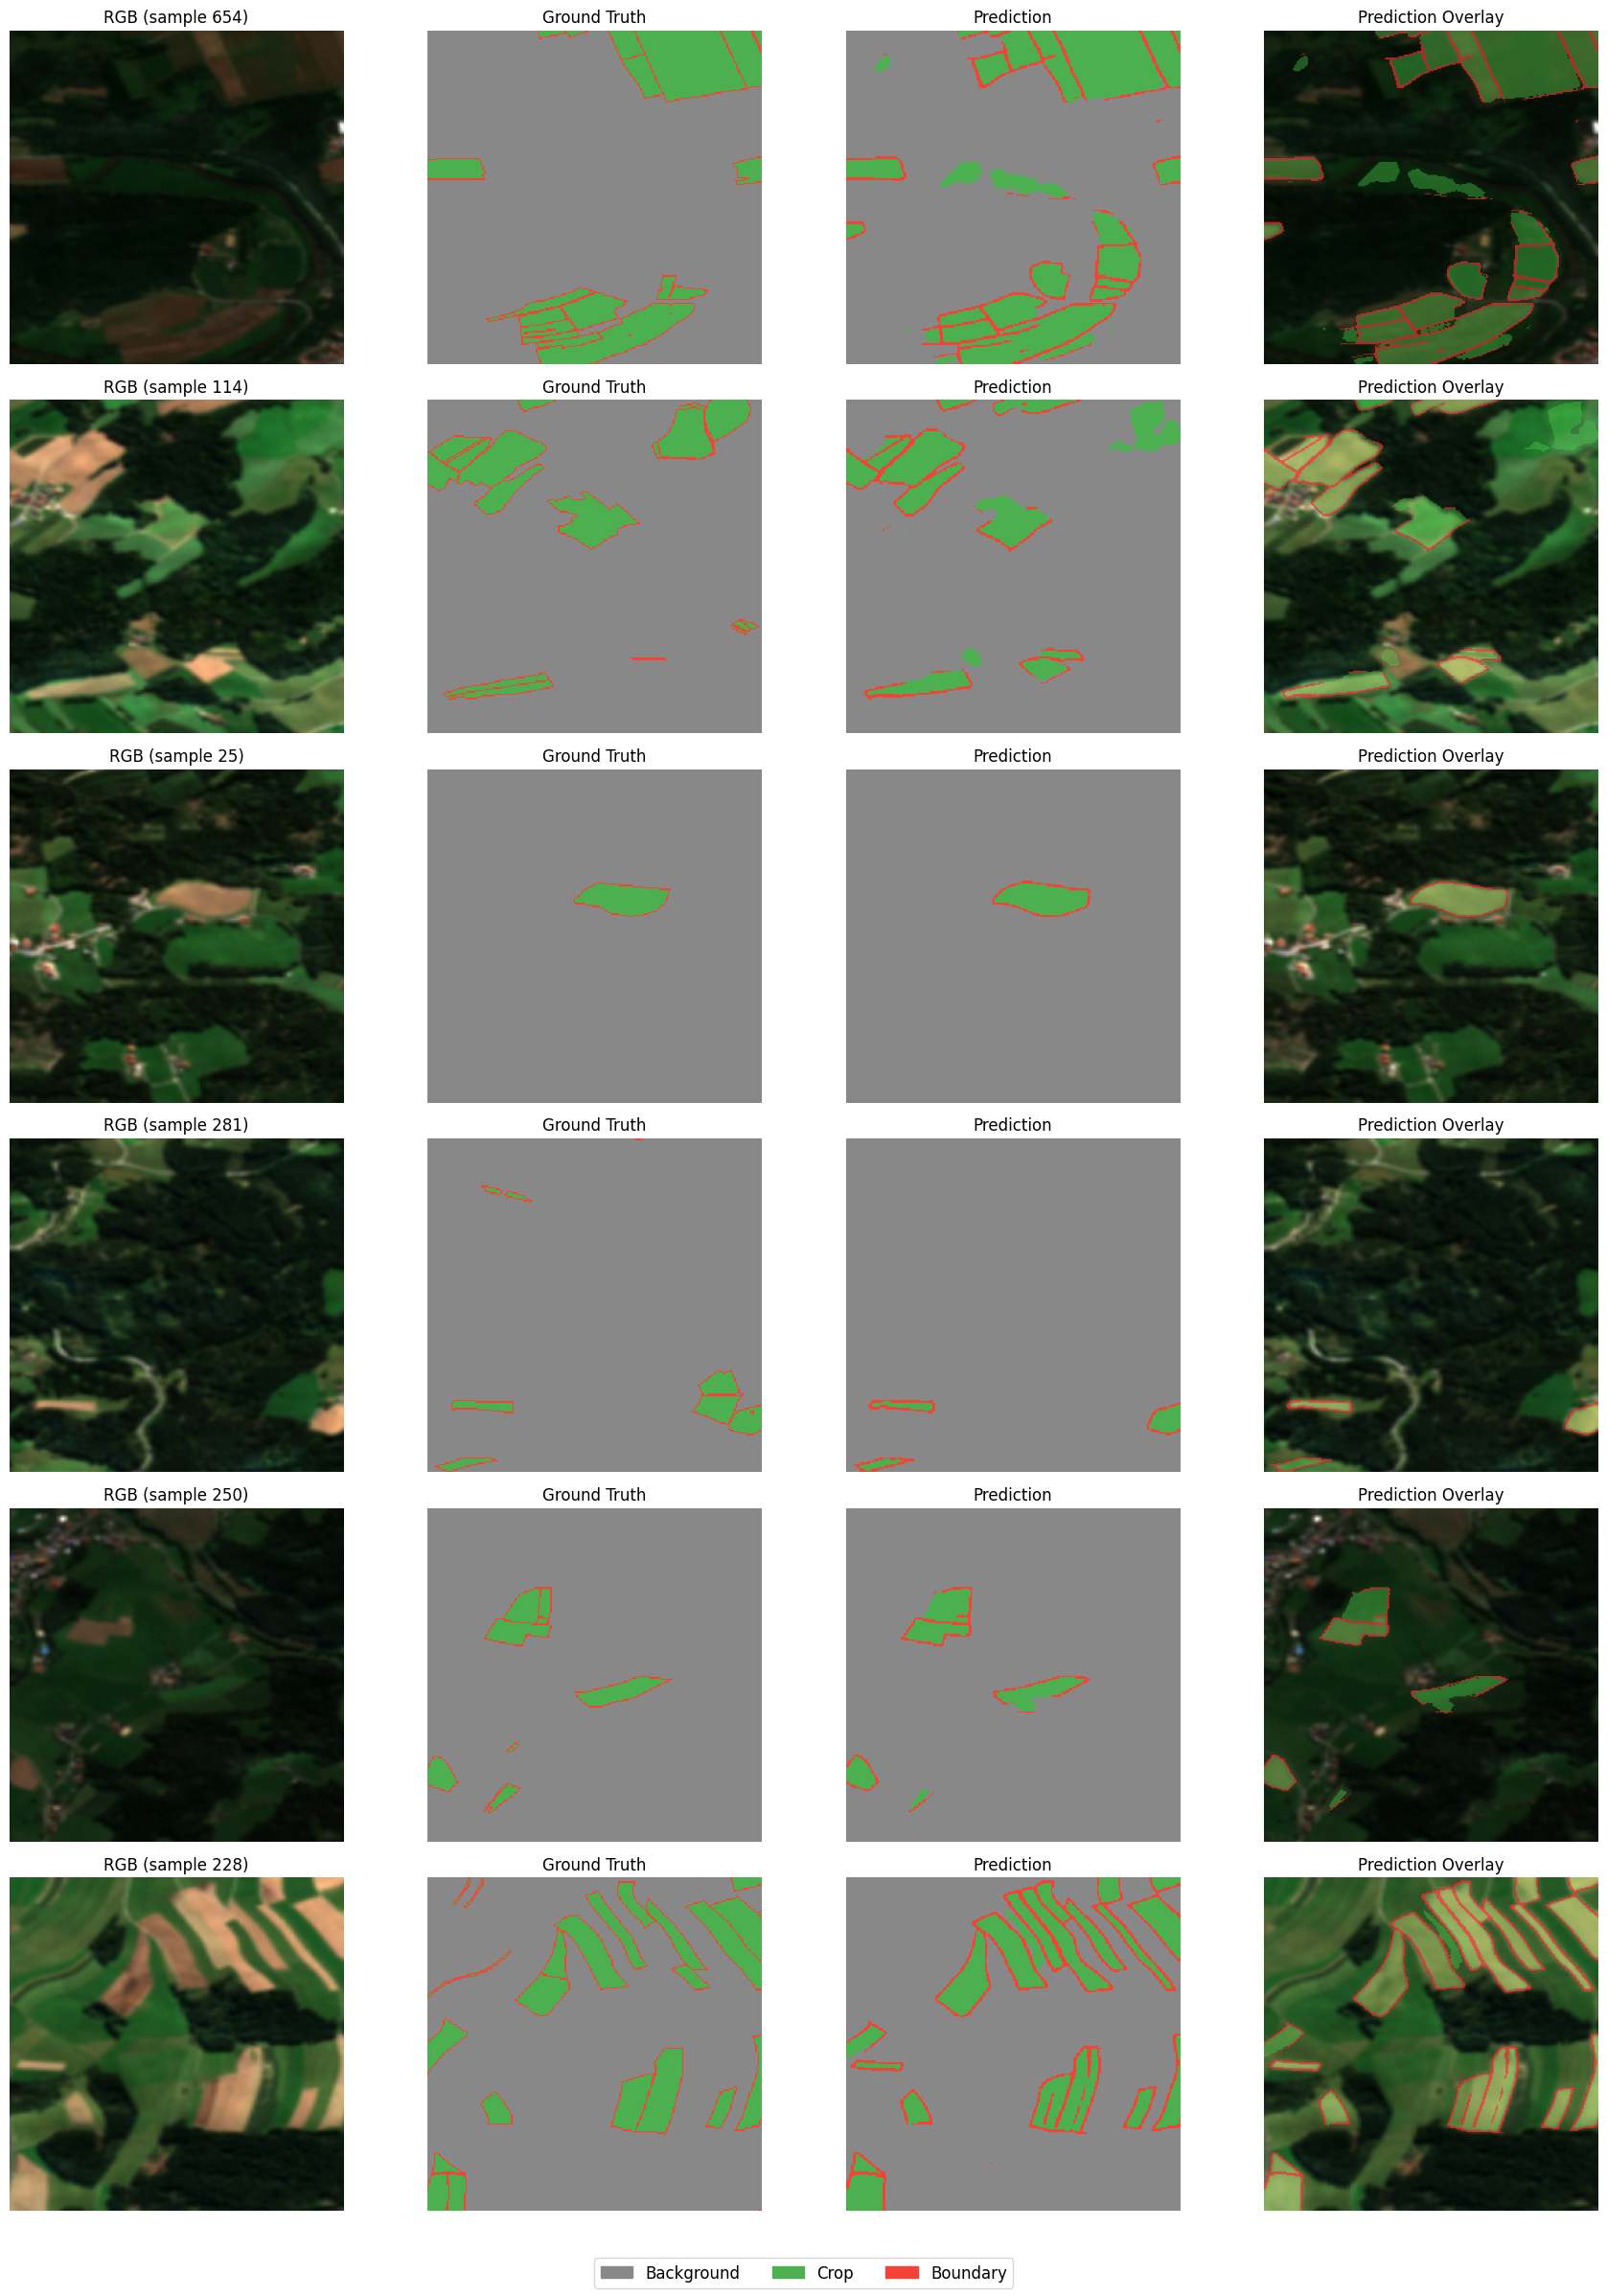

In [5]:
plot_sample_predictions(ds, indices, CHECKPOINT_FOR_TEST, TEST_DIR, CMAP)

## 3. Full-Scene Inference Output

Polygonizes each per-sample prediction TIF and shows raster + polygons side-by-side.

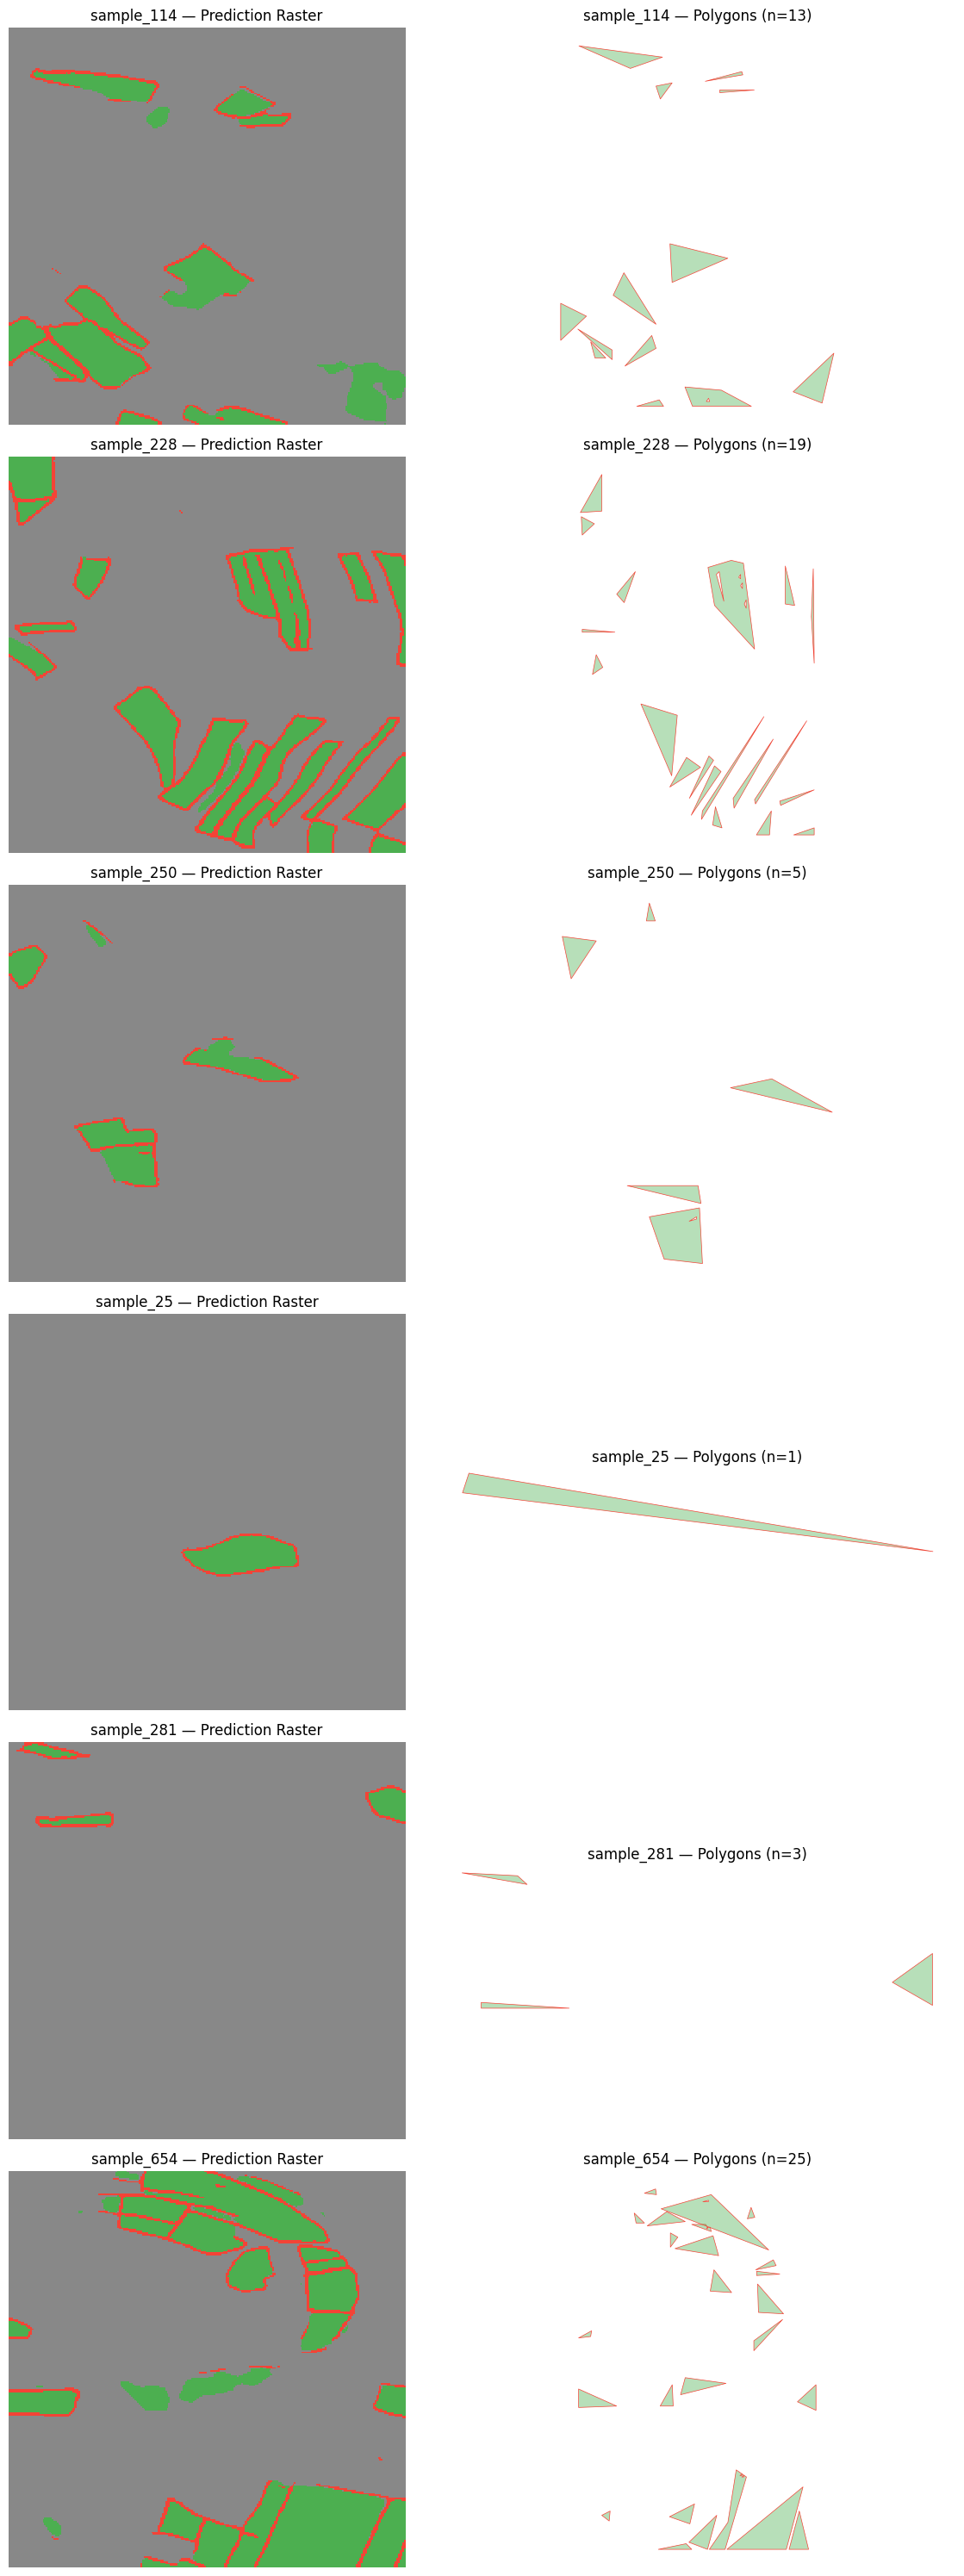

In [9]:
plot_full_scene_results(TEST_DIR, CMAP, simplify=100, min_size=500)

## 4. Polygon Size Distribution

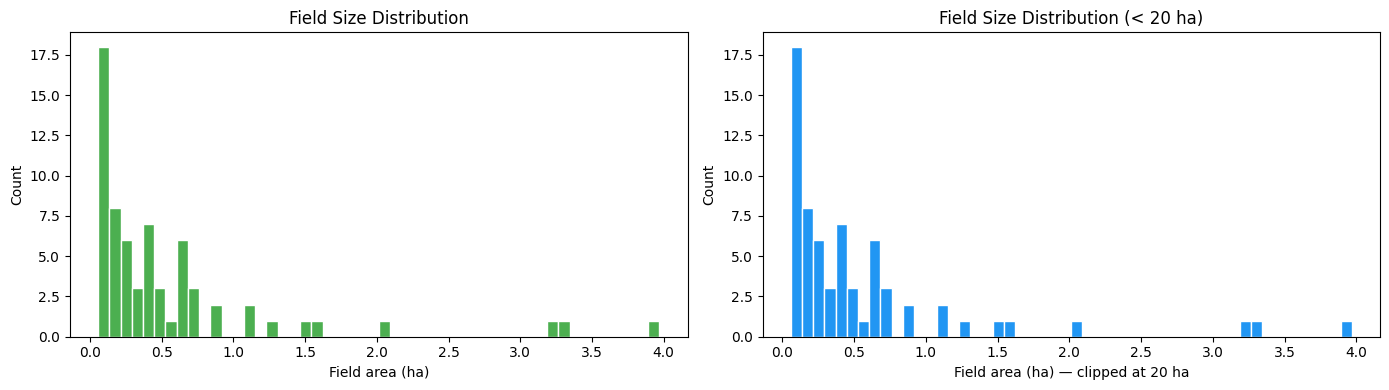

Total: 66  Median: 0.31 ha  Mean: 0.56 ha  Max: 3.97 ha


In [ ]:
plot_polygon_size_distribution(TEST_DIR)